In [1]:
!pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-kk0l1bl2
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-kk0l1bl2
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 91.9 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=6733185 sha256=ec6c9e670951f4f01865389d16328b23be6652055e4c87a6c7d1a87f6c2b71ea
  Stored in directory: /tmp/pip-ephem-wheel-cache-7kypzzr9/wheels/d3/6e/bd/1969578f1456a6be

# Import Libraries

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

from torchvision import transforms
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
from torchvision.models.detection import (
    maskrcnn_resnet50_fpn,
    MaskRCNN_ResNet50_FPN_Weights,
)

from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.data import MetadataCatalog


# Helper Function

convert integer ID mask → color mask

In [3]:
def colorize_id_mask(id_mask: np.ndarray, seed: int = 0) -> np.ndarray:
    h, w = id_mask.shape
    unique_ids = np.unique(id_mask)

    np.random.seed(seed)
    id_to_color = {
        i: np.random.randint(0, 255, (3,), dtype=np.uint8)
        for i in unique_ids
    }

    color_img = np.zeros((h, w, 3), dtype=np.uint8)
    for i in unique_ids:
        color_img[id_mask == i] = id_to_color[i]
    return color_img


# Load Image

In [4]:
IMAGE_PATH = "dogs.png"

img_pil = Image.open(IMAGE_PATH).convert("RGB")
img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise FileNotFoundError(f"Cannot read image: {IMAGE_PATH}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


# SEMANTIC SEGMENTATION (FCN)

Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:01<00:00, 95.6MB/s]



=== SEMANTIC SEGMENTATION DETECTED CLASSES ===
ID  0 → __background__
ID 12 → dog


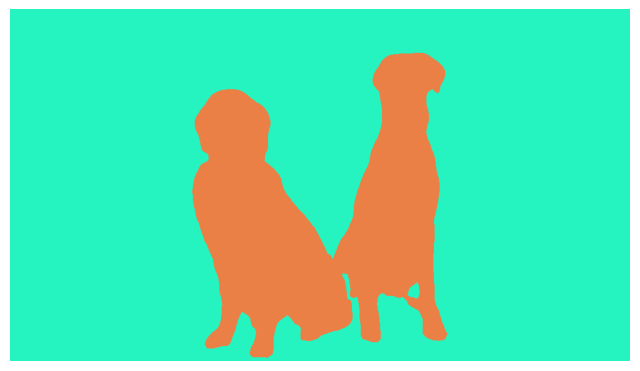

In [5]:
sem_weights = FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
sem_model = fcn_resnet50(weights=sem_weights).to(device).eval()
sem_classes = sem_weights.meta["categories"]

sem_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

sem_input = sem_transform(img_pil).unsqueeze(0).to(device)

with torch.no_grad():
    sem_logits = sem_model(sem_input)["out"]

sem_pred = sem_logits.argmax(1)[0].cpu().numpy().astype(np.int32)
sem_mask_color = colorize_id_mask(sem_pred, seed=1)

print("\n=== SEMANTIC SEGMENTATION DETECTED CLASSES ===")
for cid in np.unique(sem_pred):
    print(f"ID {cid:2d} → {sem_classes[cid]}")

plt.figure(figsize=(8, 8))
plt.imshow(sem_mask_color)
plt.axis("off")
plt.show()

# INSTANCE SEGMENTATION (Mask R-CNN)


=== INSTANCE SEGMENTATION DETECTED OBJECTS ===
dog  (score=1.00)
dog  (score=1.00)


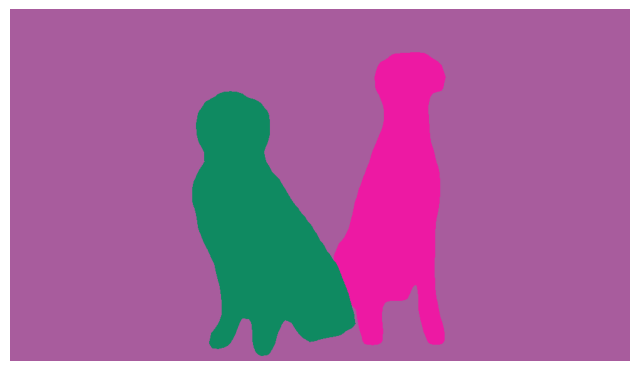

In [10]:
inst_weights = MaskRCNN_ResNet50_FPN_Weights.COCO_V1
inst_classes = inst_weights.meta["categories"]

inst_model = maskrcnn_resnet50_fpn(weights=inst_weights).to(device).eval()
inst_input = transforms.ToTensor()(img_pil).to(device)

with torch.no_grad():
    inst_out = inst_model([inst_input])[0]

inst_scores = inst_out["scores"].cpu().numpy()
inst_labels = inst_out["labels"].cpu().numpy()
inst_masks  = inst_out["masks"].cpu().numpy()

keep = inst_scores >= 0.6
inst_scores = inst_scores[keep]
inst_labels = inst_labels[keep]
inst_masks  = inst_masks[keep]

H, W = img_pil.size[1], img_pil.size[0]
inst_id_mask = np.zeros((H, W), dtype=np.int32)
order = np.argsort(-inst_scores)
current_id = 1

for idx in order:
    m = inst_masks[idx, 0] > 0.5
    m = np.logical_and(m, inst_id_mask == 0)
    if m.sum() < 50:
        continue

    inst_id_mask[m] = current_id
    current_id += 1

inst_mask_color = colorize_id_mask(inst_id_mask, seed=2)

print("\n=== INSTANCE SEGMENTATION DETECTED OBJECTS ===")
for lbl, score in zip(inst_labels, inst_scores):
    print(f"{inst_classes[lbl]}  (score={score:.2f})")

plt.figure(figsize=(8, 8))
plt.imshow(inst_mask_color)
plt.axis("off")
plt.show()


# PANOPTIC SEGMENTATION (Panoptic FPN)


=== PANOPTIC SEGMENTATION SEGMENTS (things + stuff) ===
ID  1 → dog               | thing=True
ID  2 → dog               | thing=True
ID  3 → river             | thing=False
ID  4 → water             | thing=False
ID  5 → tree              | thing=False
ID  6 → sky               | thing=False
ID  7 → grass             | thing=False
ID  8 → dirt              | thing=False


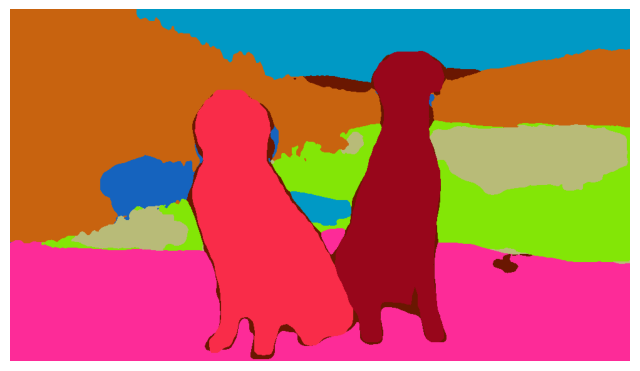

In [11]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-PanopticSegmentation/panoptic_fpn_R_50_3x.yaml"
))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-PanopticSegmentation/panoptic_fpn_R_50_3x.yaml"
)
cfg.MODEL.DEVICE = device.type

predictor = DefaultPredictor(cfg)

with torch.no_grad():
    panoptic_out = predictor(img_bgr)

panoptic_seg, segments_info = panoptic_out["panoptic_seg"]
panoptic_id_mask = panoptic_seg.cpu().numpy().astype(np.int32)
panoptic_mask_color = colorize_id_mask(panoptic_id_mask, seed=3)

meta = MetadataCatalog.get(cfg.DATASETS.TRAIN[0])

print("\n=== PANOPTIC SEGMENTATION SEGMENTS (things + stuff) ===")
for seg in segments_info:
    sid = seg["id"]
    cid = seg["category_id"]
    isthing = seg["isthing"]

    if isthing:
        name = meta.thing_classes[cid]
    else:
        name = meta.stuff_classes[cid]

    print(f"ID {sid:2d} → {name:15s}   | thing={isthing}")

plt.figure(figsize=(8, 8))
plt.imshow(panoptic_mask_color)
plt.axis("off")
plt.show()
